In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm
import time
from scipy.io import loadmat
from gravity_forward_numba import VecWerSch_numba

In [2]:
# Load EROS geometry from MATLAB file
print("=== Loading EROS Geometry ===")
eros_mat = loadmat('EROS.mat')
eros_vf = eros_mat['eros11272_22540']  # shape: (nVert + nFace, 3)

nF = 22540
nVpF = eros_vf.shape[0]
nV = nVpF - nF

Verts = eros_vf[:nV, :].astype(np.float64)
Faces = eros_vf[nV:, :].astype(np.int64)

# Bounding box (in km)
X1, X2 = Verts[:, 0].min(), Verts[:, 0].max()
Y1, Y2 = Verts[:, 1].min(), Verts[:, 1].max()
Z1, Z2 = Verts[:, 2].min(), Verts[:, 2].max()

print(f"Number of vertices : {nV}")
print(f"Number of faces    : {nF}")
print(f"Bounding box (km)  :")
print(f"  X ∈ [{X1:8.4f}, {X2:8.4f}]")
print(f"  Y ∈ [{Y1:8.4f}, {Y2:8.4f}]")
print(f"  Z ∈ [{Z1:8.4f}, {Z2:8.4f}]")

=== Loading EROS Geometry ===
Number of vertices : 11272
Number of faces    : 22540
Bounding box (km)  :
  X ∈ [-17.6345,  15.0963]
  Y ∈ [ -8.2627,   8.6053]
  Z ∈ [ -6.0352,   5.9477]


In [3]:
# Load reference gravity field computed in MATLAB
print("\n=== Loading Reference Gravity Field (MATLAB) ===")
eros_grav = loadmat('EROS_Grefs.mat')

# Extract 2D fields (keep original shape for plotting)
V_ref   = eros_grav['dV']      # (ny, nx)
gx_ref  = eros_grav['gx']
gy_ref  = eros_grav['gy']
gz_ref  = eros_grav['gz']
Txx_ref = eros_grav['Txx']
Txy_ref = eros_grav['Txy']
Txz_ref = eros_grav['Txz']
Tyy_ref = eros_grav['Tyy']
Tyz_ref = eros_grav['Tyz']
Tzz_ref = eros_grav['Tzz']

tc_matlab = eros_grav['time_cost'].item()
ny_ref, nx_ref = V_ref.shape
N_obs = nx_ref * ny_ref

print(f"Observation grid size: {nx_ref} x {ny_ref} = {N_obs} points")
print(f"MATLAB computation time: {tc_matlab:.2f} sec")


=== Loading Reference Gravity Field (MATLAB) ===
Observation grid size: 401 x 201 = 80601 points
MATLAB computation time: 297.00 sec


In [4]:
# Observation grid setup and Numba forward computation
print("\n=== Numba Forward Computation ===")
rho = 2670.0  # density in kg/m³

# Recreate the exact same grid used in MATLAB
xgv = np.linspace(-20.0, 20.0, nx_ref)
ygv = np.linspace(-10.0, 10.0, ny_ref)
X2d, Y2d = np.meshgrid(xgv, ygv)
z0 = -6.3  # observation height in km
Z2d = z0 * np.ones_like(X2d)
P = np.column_stack((X2d.ravel(), Y2d.ravel(), Z2d.ravel()))

# Run forward model
t0 = time.time()
V_cal, gx_cal, gy_cal, gz_cal, \
Txx_cal, Txy_cal, Txz_cal, Tyy_cal, Tyz_cal, Tzz_cal = \
    VecWerSch_numba(P, Verts, Faces, rho)
tc_numba = time.time() - t0

# Reshape to 2D to match reference
V_cal   = V_cal.reshape(ny_ref, nx_ref)
gx_cal  = gx_cal.reshape(ny_ref, nx_ref)
gy_cal  = gy_cal.reshape(ny_ref, nx_ref)
gz_cal  = gz_cal.reshape(ny_ref, nx_ref)
Txx_cal = Txx_cal.reshape(ny_ref, nx_ref)
Txy_cal = Txy_cal.reshape(ny_ref, nx_ref)
Txz_cal = Txz_cal.reshape(ny_ref, nx_ref)
Tyy_cal = Tyy_cal.reshape(ny_ref, nx_ref)
Tyz_cal = Tyz_cal.reshape(ny_ref, nx_ref)
Tzz_cal = Tzz_cal.reshape(ny_ref, nx_ref)

print(f"Numba computation time: {tc_numba:.2f} sec")
print(f"Speedup vs MATLAB: {tc_matlab / tc_numba:.2f}x")


=== Numba Forward Computation ===
Numba computation time: 6.60 sec
Speedup vs MATLAB: 45.01x


In [5]:
# Compute statistics: Reference, Computed, and Difference (cal - ref)
fields = ['V', 'gx', 'gy', 'gz', 'Txx', 'Txy', 'Txz', 'Tyy', 'Tyz', 'Tzz']
ref_arrays = [V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Txy_ref, Txz_ref, Tyy_ref, Tyz_ref, Tzz_ref]
cal_arrays = [V_cal, gx_cal, gy_cal, gz_cal, Txx_cal, Txy_cal, Txz_cal, Tyy_cal, Tyz_cal, Tzz_cal]

diff_arrays = [cal - ref for cal, ref in zip(cal_arrays, ref_arrays)]

def compute_stats(arrays, names):
    """Compute min, max, mean, std for each flattened array."""
    stats = {}
    for name, arr in zip(names, arrays):
        flat = arr.ravel()
        stats[name] = {
            'Min': flat.min(),
            'Max': flat.max(),
            'Mean': flat.mean(),
            'Std': flat.std()
        }
    return pd.DataFrame(stats).T

df_ref = compute_stats(ref_arrays, fields)
df_cal = compute_stats(cal_arrays, fields)
df_diff = compute_stats(diff_arrays, fields)

def print_table(df, title):
    print(f"\n{title}")
    print("=" * len(title))
    print(df.to_string(float_format="{:12.8f}".format))

print_table(df_ref, "Reference (MATLAB) — GP in m²/s², GV in mGal, GGT in Eotvos")
print_table(df_cal, "Computed (Numba Polyhedron) — GP in m²/s², GV in mGal, GGT in Eotvos")
print_table(df_diff, "Difference (Computed - Reference) — GP in m²/s², GV in mGal, GGT in Eotvos")


Reference (MATLAB) — GP in m²/s², GV in mGal, GGT in Eotvos
              Min           Max          Mean          Std
V     19.99638927   51.39304554   34.99130567   7.83149447
gx  -211.26064212  181.57852469   -0.90503439 115.06133870
gy  -239.47878688  223.43496010    0.73821813 136.18362823
gz    28.85265134  529.62300665  200.90289504 125.05960667
Txx -370.56172000  139.52956783  -53.24624370 104.50488758
Txy -278.50855018  149.16830750   -2.21225024  94.83708909
Txz -437.27793137  314.92338143   -1.98722037 169.26598501
Tyy -927.21420272  149.97822528 -129.72911027 230.31947352
Tyz -688.24652135  635.41993228    0.44820986 288.38308616
Tzz  -67.48572131 1183.54284305  182.97535397 290.36792766

Computed (Numba Polyhedron) — GP in m²/s², GV in mGal, GGT in Eotvos
              Min           Max          Mean          Std
V     19.99638927   51.39304554   34.99130567   7.83149447
gx  -211.26064212  181.57852469   -0.90503439 115.06133870
gy  -239.47878688  223.43496010    0.738218

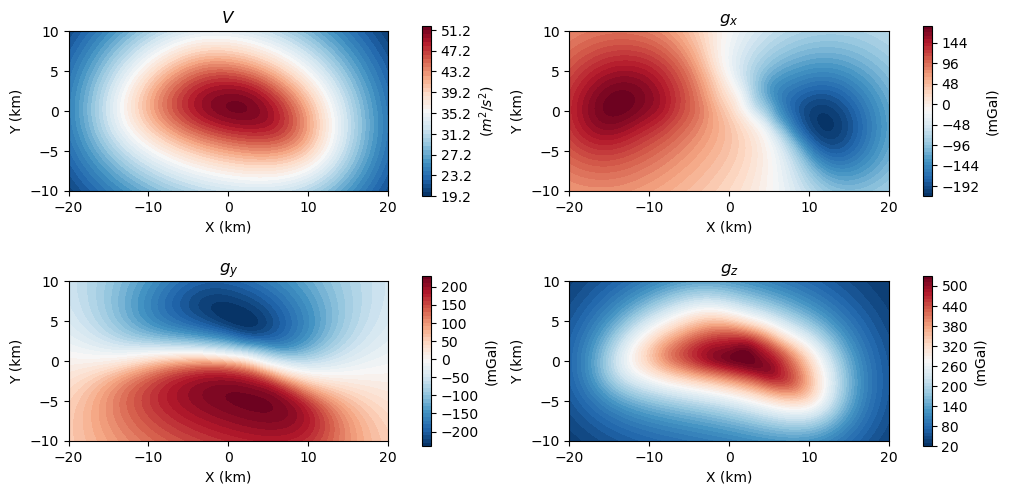

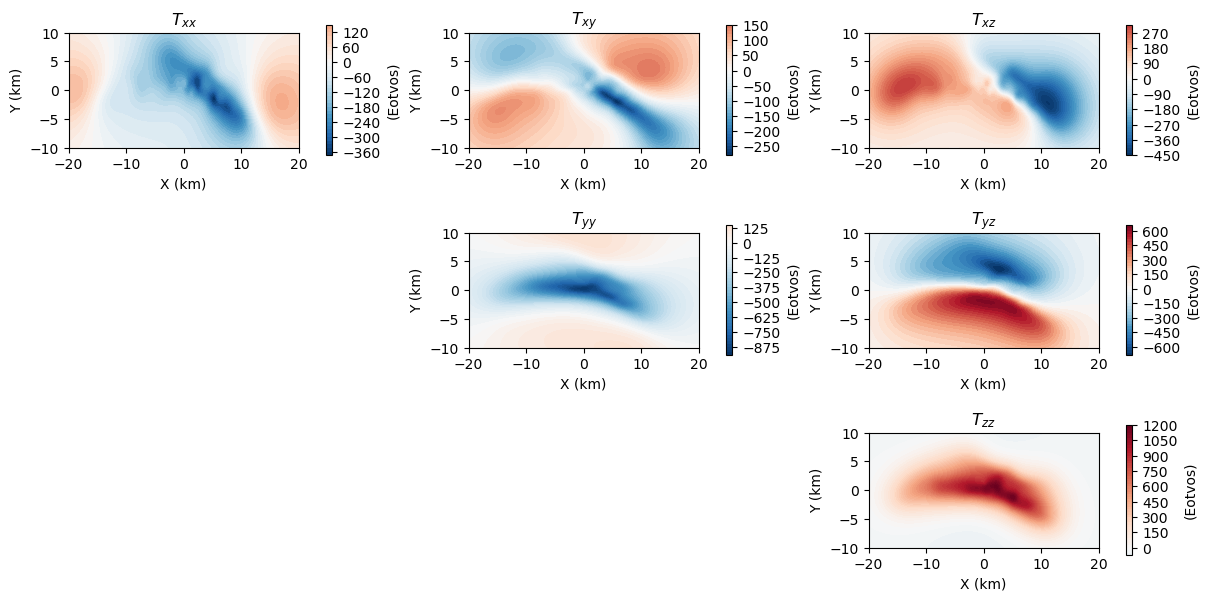

In [6]:
# Plot 1: Gravity Potential and Vector Components (2×2)
GPV = [V_cal, gx_cal, gy_cal, gz_cal]
Names = ['$V$', '$g_x$', '$g_y$', '$g_z$']
Units = ['$m^2/s^2$', 'mGal', 'mGal', 'mGal']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 5), layout='constrained')
for ax, field, name, unit in zip(axs.flat, GPV, Names, Units):
    ctf = ax.contourf(X2d, Y2d, field, levels=50, cmap='RdBu_r')
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_aspect('equal')
    ax.set_title(name, fontsize=12)
    cb = fig.colorbar(ctf, ax=ax, shrink=0.75, pad=0.08)
    cb.ax.set_ylabel(f'({unit})')

plt.savefig('EROS_2DPlane_GPV.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Gravity Gradient Tensor (GGT) — Upper triangular layout
GGT = [Txx_cal, Txy_cal, Txz_cal, Tyy_cal, Tyz_cal, Tzz_cal]
Names = ['$T_{xx}$', '$T_{xy}$', '$T_{xz}$', '$T_{yy}$', '$T_{yz}$', '$T_{zz}$']
Units = ['Eotvos'] * 6

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 6), layout='constrained')

pkaxs = [
    axs[0, 0], axs[0, 1], axs[0, 2],
               axs[1, 1], axs[1, 2],
                          axs[2, 2]
]

for ax in [axs[1, 0], axs[2, 0], axs[2, 1]]:
    ax.set_axis_off()

for ax, field, name, unit in zip(pkaxs, GGT, Names, Units):
    ctf = ax.contourf(X2d, Y2d, field, levels=50, cmap='RdBu_r', norm=CenteredNorm())
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_aspect('equal')
    ax.set_title(name, fontsize=12)
    cb = fig.colorbar(ctf, ax=ax, shrink=0.75, pad=0.08)
    cb.ax.set_ylabel(f'({unit})')

plt.savefig('EROS_2DPlane_GGT.png', dpi=300, bbox_inches='tight')
plt.show()